# Tutorial 1: From Raw Data to Normalized Methylation Probability

This tutorial and the next explain how to use the higher-level API of the `catella` package to perform nucleosome positioning Monte Carlo simulations. Here we focus on transforming the raw methylation scoring data (extracted from the `bam` file using `modkit`, see [Tutorial 0](./tut00_data_prep.ipynb)) and converting them into normalized methylation probabilities (see [Nucleosome Occupancy Model](../model.html) page). 

For those who would like to see the complete pipeline (the full list of commands) without the detailed explanation, please see the [Example Pipeline](../example_pipeline.html) page.

The following steps are conducted within a Jupyter notebook environment. Jupyter notebook is not automatically provided within the supplied Conda environment, but it can be installed as follows:

```bash
conda activate nucmc
conda install jupyterlab ipywidgets
```

<div class="alert alert-info">
    
**Note:** It is not required to use Jupyter notebook to run the commands in this tutorial. Using the terminal and the default Python interpreter will work just fine, although bash commands will need to be run without '!' preceding them.

</div>

## Prerequisite data files

To begin, we download some example DNA methylation footprinting data for the artificial fibers 601, Recon-1 (R1), and Recon-2 (R2). The data were generated via Oxford Nanopore long-read sequencing. These data are available from the GitHub repository, and they would have been automatically downloaded when doing `git clone` of the project and are stored in `example/tut01_meth_prob/experiment/raw_data` from the project root directory. The step of extracting the raw methylation scoring data from the `bam` file to a `tsv` file (i.e., [Tutorial 0](./tut00_data_prep.ipynb)) has already been done here. There are six files in this directory:
* `segments.size`: a file containing the size of each DNA fiber segment.
* `segments.fa`: a fasta file containing the underlying DNA sequence for each segment.
* `segments.fa.fai`: an index file for the fasta file to enable quick lookup of individual segments' DNA sequences.
* `chromatin.tsv.gz`: the methylation footprinting scores output from ModKit for chromatinized DNA.
* `unmethylated.tsv.gz`: footprinting scores for control samples where the DNA fibers are unmethylated.
* `methylated.tsv.gz`: footprinting scores for control samples where the fibers are fully methylated.

Let us have a quick look at the content of some of these files. `segments.size` contains the identifier and length (in bp) of the DNA segment:

In [1]:
!cat example/tut01_meth_prob/experiment/raw_data/segments.size

601	11110
R1	11220
R2	11220


And here we show the top few lines of the `chromatin.tsv.gz` file generated from ModKit:

In [2]:
!gzip -cd example/tut01_meth_prob/experiment/raw_data/chromatin.tsv.gz 2>/dev/null | head -n5

read_id	forward_read_position	ref_position	chrom	mod_strand	ref_strand	ref_mod_strand	fw_soft_clipped_start	fw_soft_clipped_end	alignment_start	alignment_end	read_length	mod_qual	mod_code	base_qual	ref_kmer	query_kmer	canonical_base	modified_primary_base	inferred	flag	motifs
d1267048-678d-40a1-a0fb-d5af1014469e	4	2	601	+	+	+	2	9	0	11110	10699	0.9550781	m	21	TGCGG	TGCGG	C	C	false	0	GC,1
d1267048-678d-40a1-a0fb-d5af1014469e	11	9	601	+	+	+	2	9	0	11110	10699	0	a	32	TGAAA	TGAAA	A	A	true	0	A,0
d1267048-678d-40a1-a0fb-d5af1014469e	12	10	601	+	+	+	2	9	0	11110	10699	0	a	32	GAAAT	GAAAT	A	A	true	0	A,0
d1267048-678d-40a1-a0fb-d5af1014469e	13	11	601	+	+	+	2	9	0	11110	10699	0	a	34	AAATA	AAATA	A	A	true	0	A,0


<div class="alert alert-info">

**Note:** It is important to keep the header when outputting the data from ModKit. `catella` uses this to identify the relevant data columns to keep for any downstream analysis. 

</div>

`catella` requires data from the following columns of the ModKit output tab-delimited file (as per modkit `extract full` output, see Tutorial 0 and <https://nanoporetech.github.io/modkit/intro_extract.html>):

| Column name  | Description                                             | Loaded column index |
|--------------|---------------------------------------------------------|---------------------|
| read_id      | name of the read                                        | 0                   |
| ref_position | aligned 0-based reference sequence position             | 1                   |
| chrom        | name of aligned contig                                  | 2                   |
| ref_strand   | strand of the reference read is aligned to              | 3                   |
| mod_qual     | probability of the base modification in the next column | 4                   |
| mod_code     | base modification code from the MM tag                  | 5                   |

## Loading the data files

The first step towards obtaining the methylation probabilities is loading the data above into a `MethPrintExperiment` object. We set up some variables for convenience:

In [3]:
from pathlib import Path

exp_dir = Path("example/tut01_meth_prob/experiment")
raw_dir = exp_dir/"raw_data"
chromsize = raw_dir/"segments.size"
fasta_file = raw_dir/"segments.fa"
test_file = raw_dir/"chromatin.tsv.gz"
unmeth_file = raw_dir/"unmethylated.tsv.gz"
meth_file = raw_dir/"methylated.tsv.gz"

To load the data, we use the method `catella.load_raw`. We provide the sequence file (`fasta_file`) and the types of methyltransferase (MTase) we used in the experiment (A and GC here, for m6A and CpG/GpC methylation, respectively), as these are needed for QC and normalization. Additionally, since these fibers were sequenced by ligating the forward and reverse strands of the same molecule together into one continuous read, the reference sequences are recorded at twice their true fiber length (e.g., `601` is 11110 bp in `segments.size` but only 5555 bp long); we therefore set the option `wrap=True` to fold positions back onto the true fiber length, combining calls from equivalent positions across the doubled reference.

In [4]:
import catella
exp_data = catella.load_raw(chromsize=chromsize, 
                            test_file=test_file,
                            unmeth_file=unmeth_file,
                            meth_file=meth_file,
                            fasta_file=fasta_file,
                            mtase=["A", "GC"],
                            wrap=True,
                            nworker=3)

Reading example/tut01_meth_prob/experiment/raw_data/chromatin.tsv.gz ...Reading example/tut01_meth_prob/experiment/raw_data/unmethylated.tsv.gz ...

Reading example/tut01_meth_prob/experiment/raw_data/methylated.tsv.gz ...


`exp_data` is a `MethPrintExperiment` object, which contains only the relevant attributes from the ModKit output that we need for running simulations later on. We can use the public attributes of `exp_data`, for instance, to find out what chromosomes are loaded and what MTases were used (as supplied above):

In [5]:
print("Chromosomes (genes): ", exp_data.chroms)
print("Types of methyltransferase(s) (MTases): ", exp_data.mtase)

Chromosomes (genes):  ('601', 'R1', 'R2')
Types of methyltransferase(s) (MTases):  ('A', 'GC')


We can also use the `raw` property to access each gene's raw data as `MethPrintData` objects. For example, the `test_data` property returns a Pandas data frame of the chromatinized (test) fiber's footprinting data (say for 601 fibers):

In [6]:
exp_data.raw["601"].test_data

,mol_index,pos,strand,mod_qual,mod_code
0,81.0,2.0,+,0.955078,m
1,81.0,9.0,+,0.000000,a
2,81.0,10.0,+,0.000000,a
3,81.0,11.0,+,0.000000,a
4,81.0,13.0,+,0.000000,a
...,...,...,...,...,...
310364,14.0,13.0,-,0.052734,a
310365,14.0,11.0,-,0.705078,a
310366,14.0,10.0,-,0.083984,a
310367,14.0,9.0,-,0.000000,a


To save storage space, `read_id` is replaced here by an integer `mol_index`; the original read IDs are recoverable via the `test_mol_id` property. The unmethylated and methylated control data are accessed the same way, via `unmeth_data`/`unmeth_mol_id` and `meth_data`/`meth_mol_id`, respectively.

<div class="alert alert-info">

**Note:** These data frames and read-ID arrays are copies — modifying them does not affect `exp_data`, and the copies are not saved. Use the `analysis` property (see below) to store any modifications or annotations. Read-ID arrays are also returned as non-writeable `numpy` arrays.
    
</div>

## Performing QC

An important step now is to determine the quality of the raw methylation scoring in individual molecules. Specifically, we would like to see whether there are molecules with a particularly low or high number of emitted methylation calls (i.e., low or high dropout rates). To this end, we plot the raw methylation scores for each data source (test, unmeth, or meth). For the remainder of this tutorial, we focus on the 601 fibers for illustration; R1 and R2 go through the exact same steps but are not shown individually here for brevity. We sort the molecules by their similarity in methylation scoring (`sort_by_linkage`) and then plot a heatmap showing the sorted values (using `plot_meth_prob`):

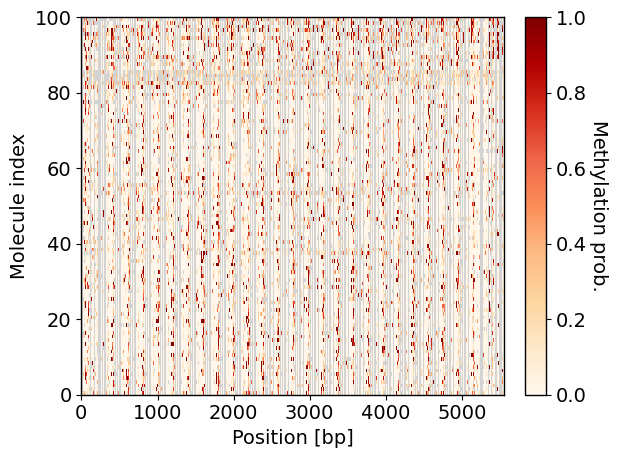

In [7]:
sorted_mat = catella.sort_by_linkage(exp=exp_data, raw_which="test", fill_nan=0.0)
catella.plot_meth_prob(exp_data.analysis["601"]["test_sorted"], vmin=0.0, vmax=1.0)

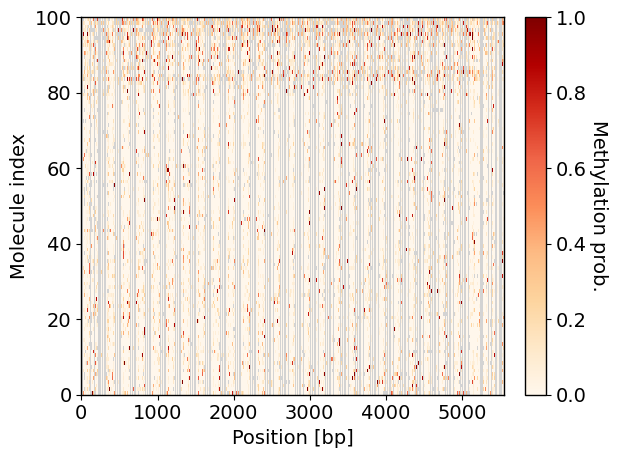

In [8]:
sorted_mat = catella.sort_by_linkage(exp=exp_data, raw_which="unmeth", fill_nan=0.0)
catella.plot_meth_prob(exp_data.analysis["601"]["unmeth_sorted"], vmin=0.0, vmax=1.0)

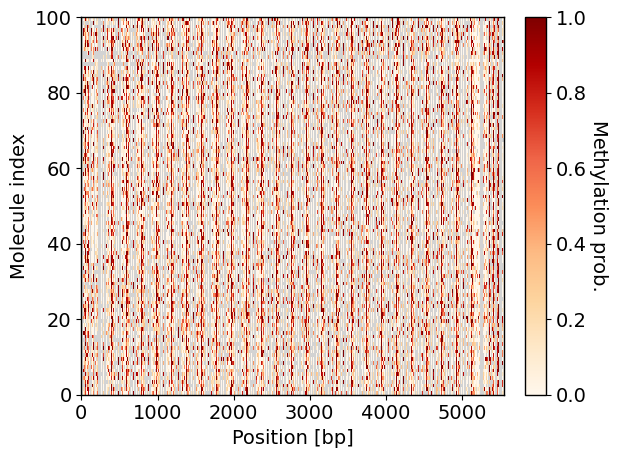

In [9]:
sorted_mat = catella.sort_by_linkage(exp=exp_data, raw_which="meth", fill_nan=0.0)
catella.plot_meth_prob(exp_data.analysis["601"]["meth_sorted"], vmin=0.0, vmax=1.0)

All heatmaps look as expected: the fully methylated fibers have the highest methylation probabilities, while the unmethylated ones have the lowest, and the actual chromatinized fibers are in between the two cases, with a tiny sub-population at the top that seems to show a higher amount of methylation. A more quantitative way to evaluate the dropout is to plot the empirical cumulative distribution function (ECDF) of the dropout rate across molecules, and this can be done via the function `plot_dropout_ecdf`:

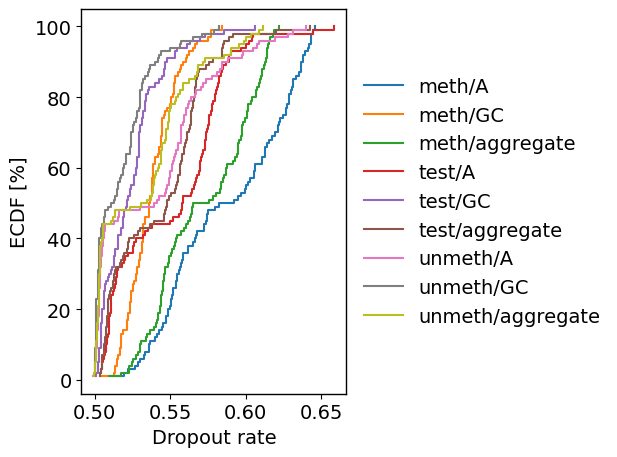

In [10]:
catella.plot_dropout_ecdf(exp=exp_data, chrom="601")

The plot shows that the dropout rate is between 0.5 and 0.65 across all channels, reflecting the limited density of CpG/GpC and m6A sites in this short, repetitive construct rather than a data-quality problem. Given that there are no obvious outliers, we will proceed without performing any filtering on the data.

## Computing normalized methylation probabilities
The next step is to convert the raw methylation scoring into methylation probabilities, and two approaches are available here. `compute_model_prob` fits a calibrated Bayesian log-odds model (see the section [Emission model data likelihood](../model.html#emission-model-data-likelihood)) and explicitly corrects for the fact that nearby methylation calls are not statistically independent, via a "per-channel" eta crosstalk factor (here we use "channel" to refer to each methylation type, e.g., the A channel for adenine sites that can be modified as m6A). It can also calibrate without meth/unmeth controls, via an expectation-maximization fit to the test data alone. 

`compute_empirical_prob` instead smooths the raw signal with a rolling window and rescales it against percentile bounds from the control data (or the test data, if no controls are given). It is simpler and faster, but does not correct for call-to-call correlation. `compute_model_prob` is generally the one to use for production runs, while `compute_empirical_prob` is useful mainly as a quick cross-check. 

Here we will show the results from both approaches, focusing on the 601 fibers. We first consider the model-based approach by running the `compute_model_prob` method:

In [11]:
exp_data = catella.compute_model_prob(exp=exp_data, prob_name="meth_prob_model")

We can view the normalized probabilities in the `analysis` map as follows:

In [12]:
exp_data.analysis["601"]["meth_prob_model"]

H5Array(shape=(100, 5555), dtype=float64, scratch)
[[1.58364714e-05 1.58364714e-05 1.08220580e-05 ...            nan
             nan            nan]
 [9.99986799e-01 9.99986799e-01 9.99989992e-01 ...            nan
             nan            nan]
 [8.50971267e-01 8.50971267e-01 8.83534322e-01 ...            nan
             nan            nan]
 ...
 [7.91384152e-02 7.91384152e-02 1.08123886e-01 ...            nan
             nan            nan]
 [1.72199829e-06 1.72199829e-06 1.22438147e-06 ...            nan
             nan            nan]
 [4.13696997e-04 4.13696997e-04 3.27139402e-04 ...            nan
             nan            nan]]

Note that, by default, the returned 2D array (with shape of $M$ molecules $\times$ $L$ bp) is of the custom type `H5Array`, where the data are stored and streamed directly from an HDF5 file and are not in RAM, due to the potential size of this array when the number of molecules is large. One can convert an `H5Array` to a regular `numpy` array using the `to_numpy` method.

<div class="alert alert-info">

**Note:** Converting an `H5Array` into a `numpy` array may lead to a large increase in memory consumption and should be done sparingly if the number of molecules is large. It is strongly encouraged to downsample or aggregate the data before making the conversion. See methods in the `catella.h5_array` module.
    
</div>

We can visualize the normalized methylation probabilities as follows (again sorted by similarity of the profiles between molecules):

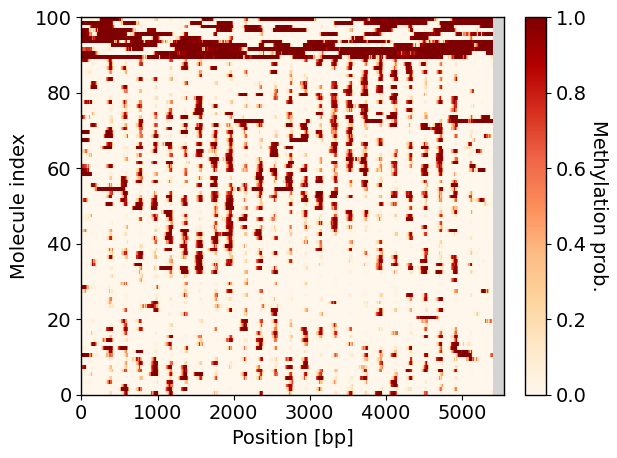

In [13]:
sorted_mat = catella.sort_by_linkage(exp=exp_data, data_name="meth_prob_model", fill_nan=0.0)
catella.plot_meth_prob(exp_data.analysis["601"]["meth_prob_model_sorted"], vmin=0.0, vmax=1.0)

The heatmap highlights the periodicity that we expect from a fiber composed of repeated 601 sequences. It also shows that there is a small subset of fibers that seem to be much more accessible, as indicated by long stretches of sites with high methylation scoring. Since the probabilities are computed based on transforming the calculated log-odds via the logistic sigmoid function (see the section [The full hamiltonian](../model.html#the-full-hamiltonian) in the Nucleosome Occupancy Model page), differences between sites with large log-odds magnitudes are subtle in this plot. Alternatively, we can view the log-odds directly using the `plot_meth_energy` function, which can reveal more details:

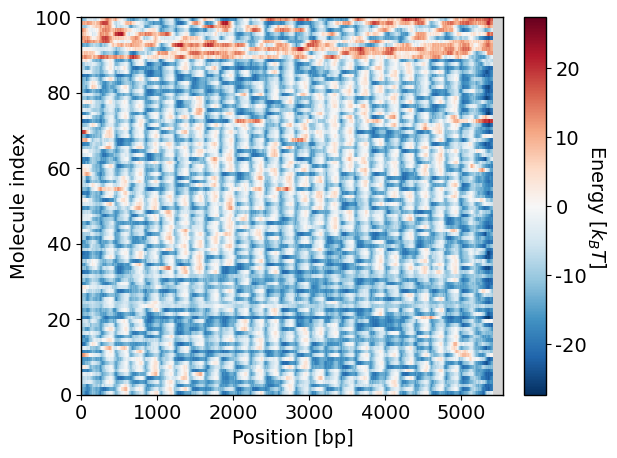

In [14]:
catella.plot_meth_energy(exp_data.analysis["601"]["meth_prob_model_sorted"])

A feature that stands out from the heatmaps above is the presence of `nan` values at the right end (the gray region). This arises because computing the likelihood involves a rolling window sum, where the window size (`lnuc`, a parameter of `compute_model_prob`) is the typical size of a nucleosome footprint on the DNA fiber \[see $\lambda_i(\vec{\theta})$ in the section [Emission model data likelihood](../model.html#emission-model-data-likelihood) in the Nucleosome Occupancy Model page]. Each window needs a reference coordinate, and this package uses a left-aligned convention (i.e., a footprint's position is its left-most coordinate) for ease of sampling nucleosome positions in the Monte Carlo simulations later.

If we prefer the probability values to be center-aligned, we can use the method `left_to_center_aligned` within the `CoordsTransform` class to transform the data before plotting:

In [15]:
from catella.mapping import CoordsTransform
lnuc = 147
coords = CoordsTransform(lnuc=lnuc)
for c in exp_data.chroms:
    exp_data.analysis[c]["meth_prob_model_centered"] = coords.left_to_center_aligned(exp_data.analysis[c]["meth_prob_model"])

We can also view the parameters used in calculating these methylation probabilities. `compute_model_prob` records three things in the experiment's `global_analysis` map, plus one per-chromosome array in `analysis`:

* Input configuration: the arguments passed to (or defaulted by) `compute_model_prob`, stored in `f"{prob_name}_params"`.
* Fitted `eta`: the per-channel crosstalk-correction factor, stored in `f"{prob_name}_eta"`.
* Calibration diagnostics: one row per chromosome (and per strand since we used `norm_by_strand=True`), stored in `f"{prob_name}_calib"`.
* Per-position fitted emission rates: the `theta_prot`/`theta_acc`/`informative` values actually used to score each chromosome, stored in `exp_data.analysis[chrom][f"{prob_name}_theta"]`.

Let us look at each in turn for our `meth_prob_model` run:

In [16]:
exp_data.global_analysis["meth_prob_model_params"]

,pi0,eta_max_lag,nu,rho_leak,min_gap,lnuc,n_min,max_iters,init_prot,init_acc,tol,fill_edge,norm_by_strand,mask_name
0,0.5,10,10.0,0.1,0.05,147,10,200,0.05,0.95,1.000000e-08,NaN,False,


This table records every input configuration value passed to (or defaulted by) `compute_model_prob` (see its docstring for what each controls). Note that `max_iters` here is only a cap: it is the maximum number of expectation-maximization (EM) iterations allowed for the no-controls rate fit, not how many were actually run, which is instead shown in the `iters` field in the calibration table below.

In [17]:
exp_data.global_analysis["meth_prob_model_eta"]

,eta_A,eta_GCH,eta_GCG
0,0.825458,0.82906,0.81692


This is the fitted crosstalk-correction factor for each channel: a value well below one indicates strong autocorrelation between nearby calls that the model corrected for.

In [18]:
exp_data.global_analysis["meth_prob_model_calib"]

,chrom,has_controls,frac_informative_A,frac_informative_GCH,frac_informative_GCG
0,601,True,0.739732,0.990937,0.997268
1,R1,True,0.801778,0.993703,0.991525
2,R2,True,0.791057,0.997207,0.991870


This table has one row per chromosome, recording what the calibration step actually did:
* `has_controls`: whether `meth`/`unmeth` controls were used for that row (`True` here since we supplied both).
* `frac_informative_<channel>`: the fraction of the channel's own sites with enough signal gap between the accessible and protected states to be used.
* `iters`, `log_likelihood`, `frac_protected`, `theta_prot_<channel>`, `theta_acc_<channel>`: these only appear for chromosomes that used the no-controls EM fit (none here since we supplied controls). When they are present, check `iters` against the `max_iters` cap above to confirm the fit converged rather than being cut off.

Since we have used controls for the normalization, we obtain per-position `theta_prot`/`theta_acc`/`informative` arrays that are used for calculating methylation probabilities for each chromosome. These data are found in `exp_data.analysis[chrom][f"{prob_name}_theta"]`:

In [19]:
exp_data.analysis["601"]["meth_prob_model_theta"]

,theta_prot,theta_acc,informative
0,0.028973,0.019498,False
1,0.040667,0.137604,True
2,0.040372,0.384865,True
3,NaN,NaN,False
4,NaN,NaN,False
...,...,...,...
5550,0.043006,0.049558,False
5551,NaN,NaN,False
5552,NaN,NaN,False
5553,NaN,NaN,False


## Obtaining the methylation probability using an empirical approach

Here we show an alternative, empirical approach for performing the normalization, whereby methylation probabilities are calculated by smoothing and rescaling the raw data. We run the `compute_empirical_prob` method to do so:

In [20]:
exp_data = catella.compute_empirical_prob(exp=exp_data, prob_name="meth_prob_empirical")

This method first smooths the data by applying a fixed-size rolling-window average to the methylation score signal for each molecule, and the default window size is the typical footprint of a nucleosome bound to DNA (147 bp). The smoothed data are stored in `exp_data.analysis`, and we can access these smoothed data, say for the chromatinized fibers (the test source), using the key `test_smoothed`:

In [21]:
exp_data.analysis["601"]["test_smoothed"]

H5Array(shape=(100, 5555), dtype=float64, scratch)
[[0.10666911 0.10666911 0.10611979 ...        nan        nan        nan]
 [0.3999242  0.3999242  0.40406709 ...        nan        nan        nan]
 [0.22790948 0.22790948 0.23310991 ...        nan        nan        nan]
 ...
 [0.19255118 0.19255118 0.19850852 ...        nan        nan        nan]
 [0.12216907 0.11749822 0.11749822 ...        nan        nan        nan]
 [0.11301398 0.11421626 0.11619016 ...        nan        nan        nan]]

Note that, as with `compute_model_prob`, the reference coordinate for each smoothing window is left-aligned, and hence the right end of the array is filled with `nan` values. After smoothing, the method normalizes the signal from the chromatinized fibers against that from the control datasets (methylated and unmethylated fibers; see the section [An empirical alternative to the likelihood](../model.html#an-empirical-alternative-to-the-likelihood) in the Nucleosome Occupancy Model page). Similar to before, we can view the resulting normalized methylation probabilities and log-odds heatmaps as follows:

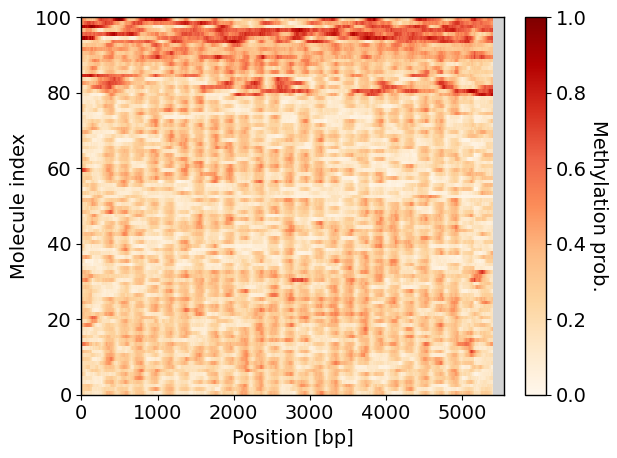

In [22]:
sorted_mat = catella.sort_by_linkage(exp=exp_data, chroms="601", data_name="meth_prob_empirical", fill_nan=0.0)
catella.plot_meth_prob(data=exp_data.analysis["601"]["meth_prob_empirical_sorted"], vmin=0.0, vmax=1.0)

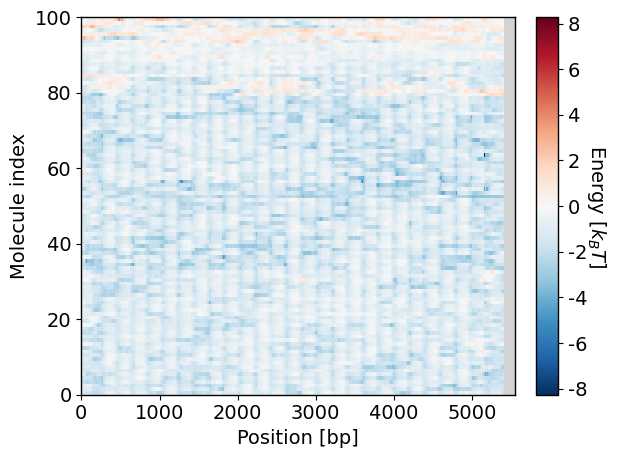

In [23]:
catella.plot_meth_energy(data=exp_data.analysis["601"]["meth_prob_empirical_sorted"])

As above, we find a small population of fibers that seem to be more accessible, with fewer nucleosomes, suggesting that both model-based and empirical-based approaches give similar results. This is now a good checkpoint to save the processed experimental data, which can be done using the `save` method. This stores the relevant raw data and analyses we have done into a single HDF5 file.

In [24]:
exp_h5 = exp_dir/"analysis.h5"
exp_data.save(exp_h5)

We can reload this file later using the `load` method:

In [25]:
from catella.experiment.methdata import MethPrintExperiment
new_exp_h5 = MethPrintExperiment.load(exp_h5)
print(new_exp_h5)

MethPrintExperiment(chroms, mtase, wrap, ignore_strand, raw, analysis, global_analysis)


Next, we will perform simulations sampling nucleosome positions based on the methylation probability profiles obtained here. See [Tutorial 2](./tut02_run_sim.ipynb) to continue.